In [1]:
pip install jupyter-collaboration

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install wbdata pandas numpy scikit-learn

In [3]:
# to find useful index
import wbdata
import pandas as pd

# get data source
sources = wbdata.get_sources()
print(sources)

# check index
indicators = wbdata.get_indicators(source=2, query='gdp')
for ind in indicators[:10]:
    print(f"ID: {ind['id']} - Name: {ind['name']}")

keywords = ['life expectancy', 'school enrollment', 'co2', 'electricity', 'unemployment']
for keyword in keywords:
    print(f"\n=== keywords: {keyword} ===")
    matches = wbdata.get_indicators(source=2, query=keyword)
    for match in list(matches)[:5]:
        print(f"ID: {match['id']} - Name: {match['name']}")

  id  name
----  --------------------------------------------------------------------
   1  Doing Business
   2  World Development Indicators
   3  Worldwide Governance Indicators
   5  Subnational Malnutrition Database
   6  International Debt Statistics
  11  Africa Development Indicators
  12  Education Statistics
  13  Enterprise Surveys
  14  Gender Statistics
  15  Global Economic Monitor
  16  Health Nutrition and Population Statistics
  18  IDA Results Measurement System
  19  Millennium Development Goals
  20  Quarterly Public Sector Debt
  22  Quarterly External Debt Statistics SDDS
  23  Quarterly External Debt Statistics GDDS
  25  Jobs
  27  Global Economic Prospects
  28  Global Findex database
  29  The Atlas of Social Protection: Indicators of Resilience and Equity
  30  Exporter Dynamics Database – Indicators at Country-Year Level
  31  Country Policy and Institutional Assessment
  32  Global Financial Development
  33  G20 Financial Inclusion Indicators
  34  Global P

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# define index

indicators = {
    'NY.GDP.PCAP.CD': 'GDP_per_capita',              # 人均GDP（美元）
    'SP.DYN.LE00.IN': 'Life_expectancy',             # 预期寿命（年）
    'SE.PRE.ENRR': 'School_enrollment',              # 学前教育入学率（%）
    'EN.GHG.ALL.PC.CE.AR5': 'CO2_equivalent',        # 人均温室气体排放（吨CO2当量）
    'EG.ELC.ACCS.ZS': 'Electricity_access',          # 电力接入率（%）
    'SL.UEM.TOTL.ZS': 'Unemployment_rate'            # 失业率（%）
}


for code, name in indicators.items():
    print(f"  {code} -> {name}")

  NY.GDP.PCAP.CD -> GDP_per_capita
  SP.DYN.LE00.IN -> Life_expectancy
  SE.PRE.ENRR -> School_enrollment
  EN.GHG.ALL.PC.CE.AR5 -> CO2_equivalent
  EG.ELC.ACCS.ZS -> Electricity_access
  SL.UEM.TOTL.ZS -> Unemployment_rate


In [5]:
# download data
data_date = '2020'

data_dict = {}
for code, name in indicators.items():
    try:
        series = wbdata.get_series(code, date=data_date)
        data_dict[name] = series
        print(f"  ok {name}")
    except Exception as e:
        print(f"  failed {name}")
        data_dict[name] = pd.Series(dtype=float)

data_raw = pd.DataFrame(data_dict)
print(f"\nrow data: {data_raw.shape}")

  ok GDP_per_capita
  ok Life_expectancy
  ok School_enrollment
  ok CO2_equivalent
  ok Electricity_access
  ok Unemployment_rate

row data: (266, 6)


In [6]:
# only keep country
all_countries = wbdata.get_countries()

# filter region
country_names = set()
for country in all_countries:
    if country.get('region', {}).get('id') not in ['', 'NA', None]:
        if country.get('adminregion', {}).get('id') not in ['', 'NA', None]:
            country_names.add(country['name'])

print(f"countries numb of World Bank dataset: {len(country_names)}")

# 过滤数据，只保留国家
data_countries = data_raw[data_raw.index.isin(country_names)]

print(f"afetr filtering the numb of countries is: {len(data_countries)}")

if len(data_countries) > 0:
    print("\ncountries for first 20:")
    for i, country in enumerate(sorted(data_countries.index)[:20]):
        print(f"  {i+1}. {country}")

countries numb of World Bank dataset: 129
afetr filtering the numb of countries is: 129

countries for first 20:
  1. Afghanistan
  2. Albania
  3. Algeria
  4. Angola
  5. Argentina
  6. Armenia
  7. Azerbaijan
  8. Bangladesh
  9. Belarus
  10. Belize
  11. Benin
  12. Bhutan
  13. Bolivia
  14. Bosnia and Herzegovina
  15. Botswana
  16. Brazil
  17. Burkina Faso
  18. Burundi
  19. Cabo Verde
  20. Cambodia


In [7]:
# data cleaning 

# check missing
print("Missing value stat:")
missing_before = data_countries.isnull().sum()
for col in data_countries.columns:
    missing_count = missing_before[col]
    missing_pct = (missing_count / len(data_countries)) * 100
    print(f"  {col}: {missing_count} ({missing_pct:.1f}%)")

# delete any with missing value
data_clean = data_countries.dropna()
countries_removed = len(data_countries) - len(data_clean)
print(f"\ndelete {countries_removed} countries")
print(f"remian numb: {len(data_clean)}")


# final country list
if len(data_clean) > 0:
    country_list_sorted = sorted(data_clean.index.tolist())
    print(f"\nthe number of remain countries {len(country_list_sorted)} :")
    for i, country in enumerate(country_list_sorted[:30]):
        print(f"  {i+1}. {country}")
    if len(country_list_sorted) > 30:
        print(f"  and last {len(country_list_sorted)-30}")

Missing value stat:
  GDP_per_capita: 4 (3.1%)
  Life_expectancy: 0 (0.0%)
  School_enrollment: 48 (37.2%)
  CO2_equivalent: 5 (3.9%)
  Electricity_access: 1 (0.8%)
  Unemployment_rate: 7 (5.4%)

delete 57 countries
remian numb: 72

the number of remain countries 72 :
  1. Albania
  2. Argentina
  3. Armenia
  4. Azerbaijan
  5. Bangladesh
  6. Belarus
  7. Belize
  8. Benin
  9. Bhutan
  10. Bolivia
  11. Bosnia and Herzegovina
  12. Brazil
  13. Burkina Faso
  14. Burundi
  15. Cambodia
  16. China
  17. Colombia
  18. Congo, Dem. Rep.
  19. Cote d'Ivoire
  20. Cuba
  21. Djibouti
  22. Dominican Republic
  23. Ecuador
  24. Fiji
  25. Gambia, The
  26. Georgia
  27. Ghana
  28. Guatemala
  29. Guinea
  30. Honduras
  and last 42


In [8]:
# standardize data

if len(data_clean) > 0:
    scaler = StandardScaler()
    features = data_clean.values
    features_scaled = scaler.fit_transform(features)

    data_scaled = pd.DataFrame(
        features_scaled,
        index=data_clean.index,
        columns=data_clean.columns
    )

    print("before standardize:")
    for col in data_clean.columns:
        print(f"  {col}: {data_clean[col].min():.2f} - {data_clean[col].max():.2f}")

    print("\nafter:")
    for col in data_scaled.columns:
        print(f"  {col}: {data_scaled[col].min():.2f} - {data_scaled[col].max():.2f}")

    # store cleaned& original data
    data_scaled.to_csv('data_clean.csv')
    data_clean.to_csv('data_original.csv')

    # store selected country list 
    with open('country_list.txt', 'w', encoding='utf-8') as f:
        for i, country in enumerate(country_list_sorted):
            # 格式感觉不好用可以在这里改
            f.write(f"{i+1}. {country}\n")

    # data description 数据描述
    with open('data_dictionary.txt', 'w', encoding='utf-8') as f:
        f.write(f"data source: World Bank Open Data (2020)\n")
        f.write(f"number of selected countries: {len(data_scaled)}\n")
        f.write(f"number of index: {len(data_scaled.columns)}\n\n")
        
        f.write("index list:\n")
        f.write("  GDP_per_capita (NY.GDP.PCAP.CD)\n")
        f.write("    descip: GDP（$）- level of economic development\n")
        f.write("  Life_expectancy (SP.DYN.LE00.IN)\n")
        f.write("    descip: Life expectancy at birth (years) - The level of medical health\n")
        f.write("  School_enrollment (SE.PRE.ENRR)\n")
        f.write("    descip: Gross enrollment rate of preschool education (%) - level of education\n\n")
        f.write("  CO2_equivalent (EN.GHG.ALL.PC.CE.AR5)\n")
        f.write("    descrip: Greenhouse gas emissions per capita (tonnes of CO2 equivalent) - Environmental pressures\n")
        f.write("  Electricity_access (EG.ELC.ACCS.ZS)\n")
        f.write("    descrip: Electricity Access Rate (%) - Infrastructure level\n")
        f.write("  Unemployment_rate (SL.UEM.TOTL.ZS)\n")
        f.write("    descrip: Unemployment Rate (%) - Job market conditions\n")
        
        # f.write("data preprocess预处理:\n")
        # f.write("-" * 30 + "\n")
        # f.write("1. 过滤只保留国家（排除地区和收入组别）\n")
        # f.write("2. 删除有任何指标缺失的国家\n")
        # f.write("3. 使用 StandardScaler 进行标准化（均值为0，标准差为1）\n\n")
        
        f.write("data stat:\n")
        f.write(data_clean.describe().to_string())
    

    # print(f"  1. data_clean.csv - 标准化后的数据（用于聚类）")
    # print(f"  2. data_original.csv - 原始数据（备份）")
    # print(f"  3. country_list.txt - 国家列表")
    # print(f"  4. data_dictionary.txt - 数据说明文档")

    # print(f"  国家数量: {len(data_scaled)}")
    # print(f"  指标数量: {len(data_scaled.columns)}")
    # print(f"  数据维度: {data_scaled.shape}")

before standardize:
  GDP_per_capita: 255.83 - 10627.46
  Life_expectancy: 58.86 - 78.71
  School_enrollment: 6.37 - 128.48
  CO2_equivalent: 0.52 - 20.97
  Electricity_access: 9.10 - 100.00
  Unemployment_rate: 0.17 - 29.22

after:
  GDP_per_capita: -1.44 - 2.36
  Life_expectancy: -2.01 - 1.64
  School_enrollment: -1.65 - 2.21
  CO2_equivalent: -0.99 - 4.51
  Electricity_access: -2.94 - 0.61
  Unemployment_rate: -1.20 - 3.35


Part B↓

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# read clean data
df = pd.read_csv('data_clean.csv')
print(df.head())
print(f"\nshape: {df.shape}")
print(f"\columns name: {list(df.columns)}")

#去drop 'country'
X = df.drop('country', axis=1)  #to be X
print(f"X: {list(X.columns)}")

      country  GDP_per_capita  Life_expectancy  School_enrollment  \
0     Albania        0.672601         1.473736           0.524800   
1   Argentina        1.590696         1.116156           0.557958   
2     Armenia        0.028525         0.656337          -0.381014   
3  Azerbaijan        0.014330         0.093393          -0.440156   
4  Bangladesh       -0.710960         0.297174          -0.411202   

   CO2_equivalent  Electricity_access  Unemployment_rate  
0       -0.278637            0.609336           0.596560  
1        0.978932            0.609336           0.568684  
2       -0.195505            0.609336           1.620163  
3        0.318788            0.609336          -0.092367  
4       -0.801611            0.460868          -0.358761  

shape: (72, 7)
\columns name: ['country', 'GDP_per_capita', 'Life_expectancy', 'School_enrollment', 'CO2_equivalent', 'Electricity_access', 'Unemployment_rate']
X: ['GDP_per_capita', 'Life_expectancy', 'School_enrollment', 'CO2_eq

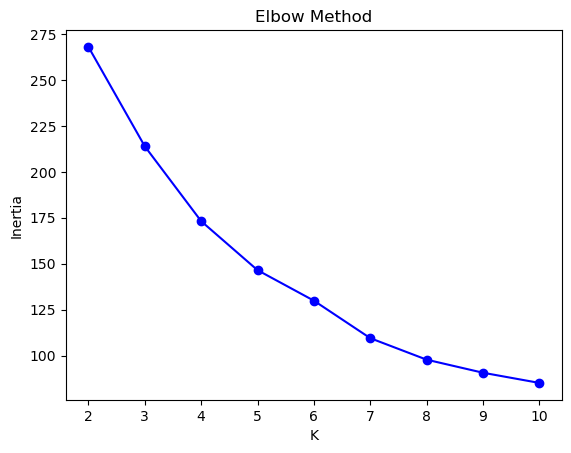

In [3]:
#确定K值
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_) # 记录 inertia

# 绘制肘部图 x=K，y=Inertia（每个点到它所属簇中心的距离平方和）
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

K=2: 0.3768
K=3: 0.2459
K=4: 0.2810
K=5: 0.2777
K=6: 0.2743
K=7: 0.3051
K=8: 0.2877
K=9: 0.2962
K=10: 0.2827


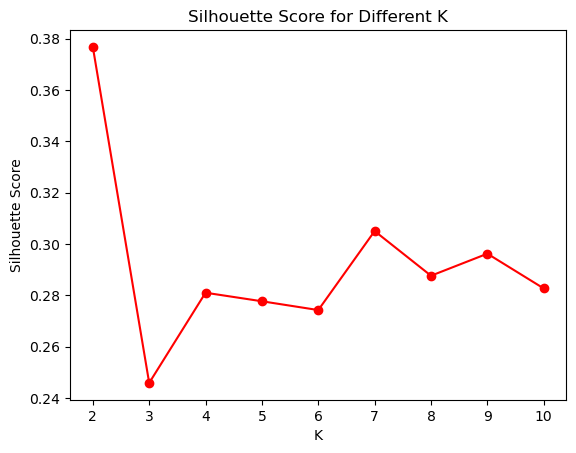

In [4]:
#计算轮廓系数（Silhouette Score）：点到同簇其他点的平均距离和点到最近其他簇的平均距离.轮廓系数越高越好
silhouette_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)                # 得到聚类标签
    score = silhouette_score(X, labels)           # 计算轮廓系数
    silhouette_scores.append(score)
    print(f"K={k}: {score:.4f}")

# 绘图
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K')
plt.show()

#决定K值：逻辑
# 1. 看肘部图，找到 1-3 个候选 K（拐点位置）
# 2. 看轮廓系数，选最高的那个候选 K
# 3. 如果两者冲突，优先相信轮廓系数

In [5]:
# 找轮廓系数最高的K
best_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"best-silhouette score → K={best_k_silhouette} (score={max(silhouette_scores):.4f})")

# 找肘部拐点（简易方法：找 inertia 下降速度变慢的点）
inertia_pct_diffs = [(inertias[i] - inertias[i+1]) / inertias[i] * 100 
                     for i in range(len(inertias)-1)]
print(f"Inertia % diff: {[round(d,2) for d in inertia_pct_diffs]}")

best-silhouette score → K=2 (score=0.3768)
Inertia % diff: [20.2, 19.05, 15.41, 11.34, 15.72, 10.7, 7.28, 6.12]


In [13]:
# K值选择为3
best_k = 3
print(f"\nbest- K = {best_k}")
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X)

print("\nClustering results：")
print(df[['country', 'cluster']].head(10))
print(f"\nNumber of clusters：")
print(df['cluster'].value_counts().sort_index())

# 查看每个簇的特征均值
cluster_profiles = df.groupby('cluster')[X.columns].mean()
print(cluster_profiles)


best- K = 3

Clustering results：
      country  cluster
0     Albania        1
1   Argentina        1
2     Armenia        1
3  Azerbaijan        0
4  Bangladesh        0
5     Belarus        1
6      Belize        0
7       Benin        2
8      Bhutan        0
9     Bolivia        0

Number of clusters：
cluster
0    25
1    30
2    17
Name: count, dtype: int64
         GDP_per_capita  Life_expectancy  School_enrollment  CO2_equivalent  \
cluster                                                                       
0             -0.389866         0.104926           0.071937       -0.330660   
1              0.926554         0.734751           0.431310        0.696869   
2             -1.061763        -1.450921          -0.866925       -0.743504   

         Electricity_access  Unemployment_rate  
cluster                                         
0                  0.419766          -0.364524  
1                  0.585764           0.458670  
2                 -1.651004          -0.27

In [14]:
# Cluster feature summary statistics
for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n{'='*50}")
    print(f"Cluster {cluster_id} ({len(df[df.cluster == cluster_id])} countries)")
    print(f"{'='*50}")
    
    cluster_data = df[df.cluster == cluster_id][X.columns]
    
    summary = pd.DataFrame({
        'Mean': cluster_data.mean(),
        'Median': cluster_data.median(),
        'Std': cluster_data.std(),
        'Min': cluster_data.min(),
        'Max': cluster_data.max()
    })
    
    print(summary.round(4))


Cluster 0 (25 countries)
                      Mean  Median     Std     Min     Max
GDP_per_capita     -0.3899 -0.3658  0.4613 -1.1117  0.4660
Life_expectancy     0.1049  0.1068  0.5497 -1.2675  1.3091
School_enrollment   0.0719 -0.2964  0.8247 -0.9901  1.8238
CO2_equivalent     -0.3307 -0.3992  0.3547 -0.8016  0.4585
Electricity_access  0.4198  0.4960  0.2897 -0.6683  0.6093
Unemployment_rate  -0.3645 -0.3973  0.5242 -1.1993  0.8155

Cluster 1 (30 countries)
                      Mean  Median     Std     Min     Max
GDP_per_capita      0.9266  0.8825  0.7486 -0.3618  2.3566
Life_expectancy     0.7348  0.7686  0.5522 -0.8551  1.6371
School_enrollment   0.4313  0.5560  0.8221 -1.3000  1.7506
CO2_equivalent      0.6969  0.3999  1.1959 -0.6722  4.5133
Electricity_access  0.5858  0.6093  0.0751  0.2186  0.6093
Unemployment_rate   0.4587  0.2183  1.0791 -1.0541  3.3495

Cluster 2 (17 countries)
                      Mean  Median     Std     Min     Max
GDP_per_capita     -1.0618 -1.1853  0

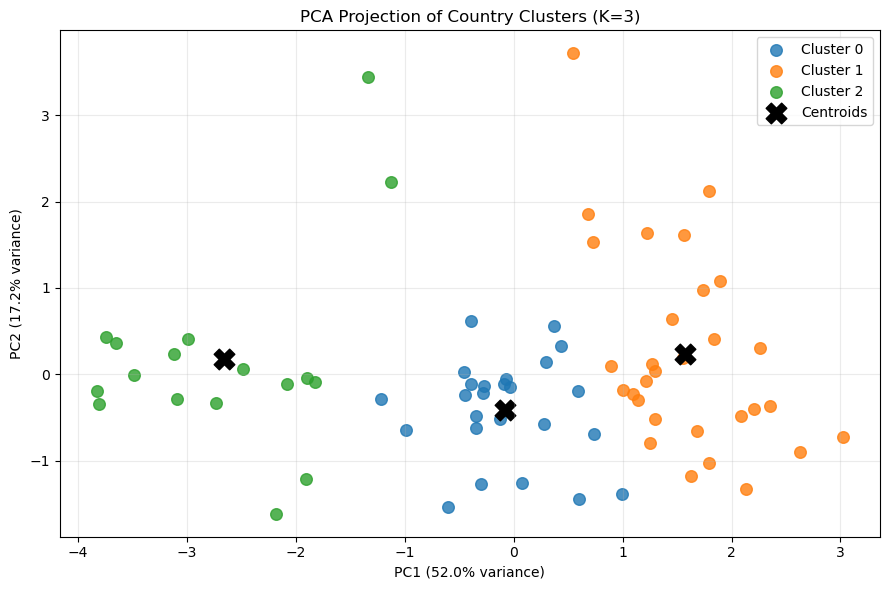

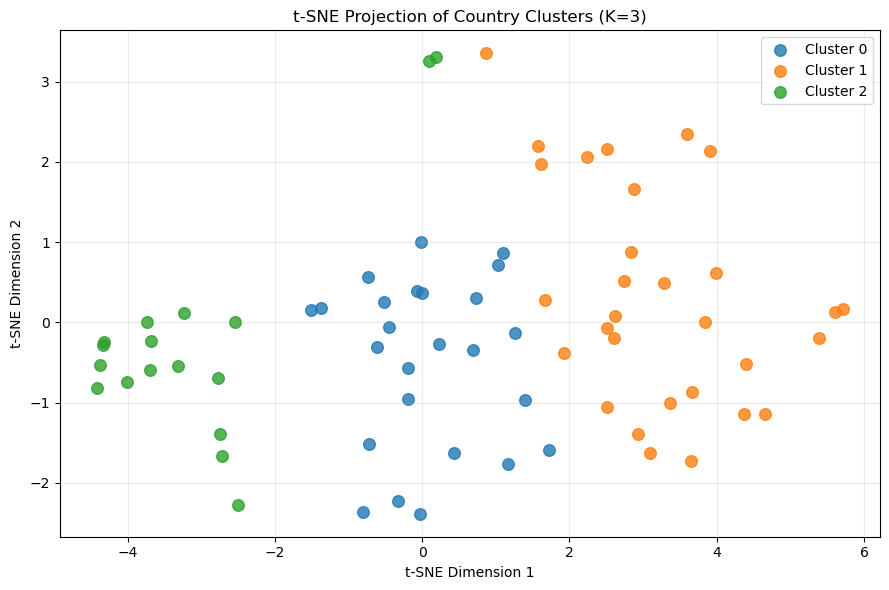

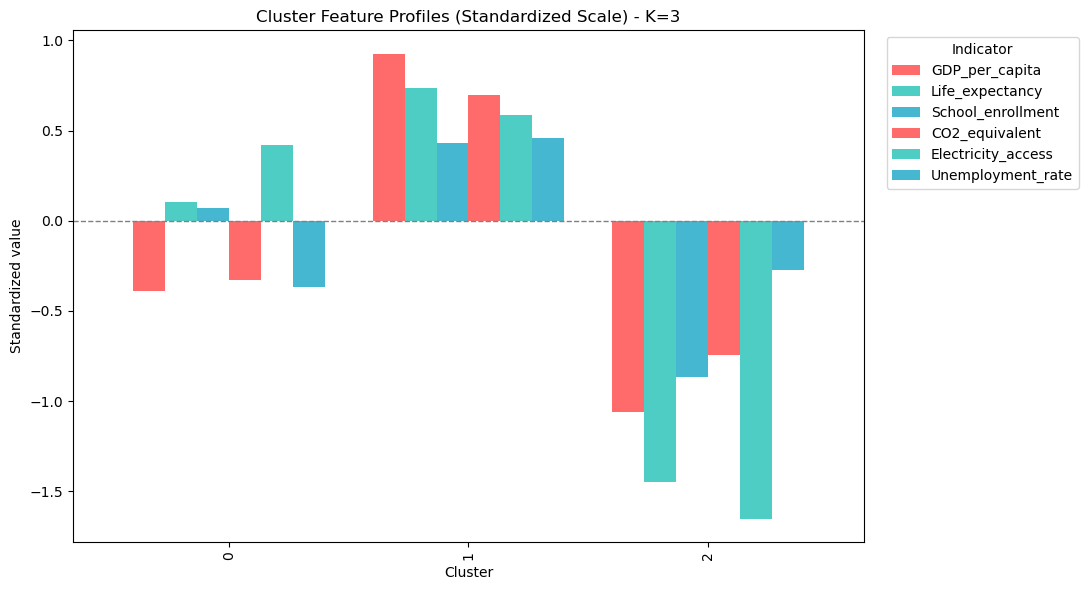

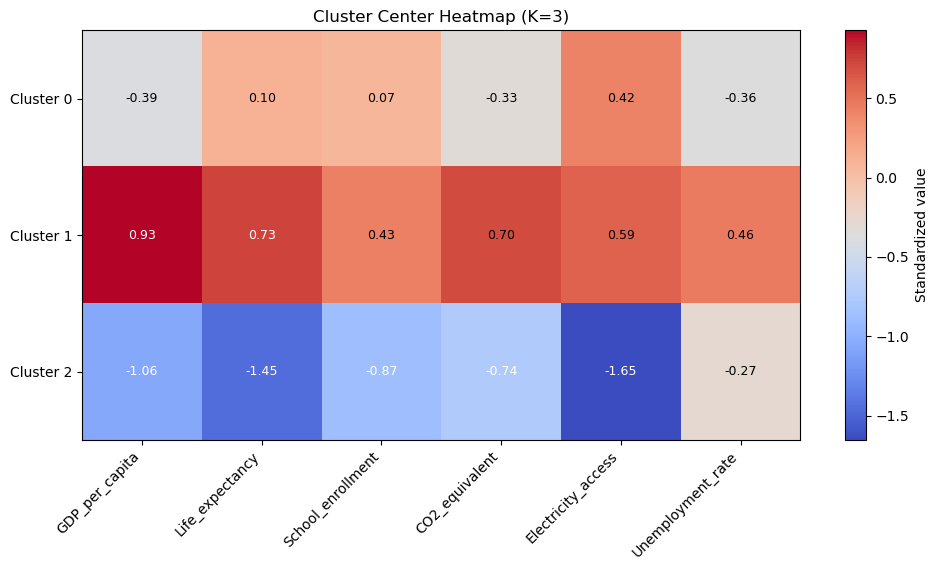


PCA Explained Variance Ratio:
  PC1: 0.5197 (52.0%)
  PC2: 0.1716 (17.2%)
  Total explained: 69.1%

Cluster Interpretation Summary (K=3):

Cluster 0:
  📈 Higher than average: Electricity_access, Life_expectancy
  📉 Lower than average: GDP_per_capita, Unemployment_rate

Cluster 1:
  📈 Higher than average: GDP_per_capita, Life_expectancy
  📉 Lower than average: School_enrollment, Unemployment_rate

Cluster 2:
  📈 Higher than average: Unemployment_rate, CO2_equivalent
  📉 Lower than average: Electricity_access, Life_expectancy

Cluster Sizes:
  Cluster 0: 25 countries
  Cluster 1: 30 countries
  Cluster 2: 17 countries


In [15]:
# Part C: visualization + interpretation
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ============================================
# 确保变量存在（根据你们实际的变量名）
# ============================================

# 假设你们已有的变量：
# X: 标准化后的特征矩阵（不含 country 列）
# df: 包含 'cluster' 列的数据框
# kmeans_final: 训练好的 KMeans 模型（K=3）

# 如果没有 kmeans_final，需要重新训练：
# kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
# kmeans_final.fit(X)
# df['cluster'] = kmeans_final.predict(X)

# 提取聚类标签和中心
final_labels = df['cluster'].values
final_model = kmeans_final
data_scaled = X.values  # 如果 X 是 DataFrame，用 .values

# 获取聚类中心（标准化后的）
cluster_centers_scaled = pd.DataFrame(
    final_model.cluster_centers_,
    columns=X.columns if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]
)
cluster_centers_scaled.index.name = 'Cluster'

# ============================================
# 1. PCA 散点图
# ============================================
if len(data_scaled) > 2:
    pca = PCA(n_components=2, random_state=42)
    pca_components = pca.fit_transform(data_scaled)
    pca_df = pd.DataFrame(
        pca_components,
        columns=['PC1', 'PC2'],
        index=data_scaled.index if hasattr(data_scaled, 'index') else range(len(data_scaled))
    )
    pca_df['Cluster'] = final_labels

    plt.figure(figsize=(9, 6))
    for cluster_id in sorted(pca_df['Cluster'].unique()):
        subset = pca_df[pca_df['Cluster'] == cluster_id]
        plt.scatter(subset['PC1'], subset['PC2'], s=70, alpha=0.8, label=f'Cluster {cluster_id}')

    pca_centers = pca.transform(final_model.cluster_centers_)
    plt.scatter(
        pca_centers[:, 0],
        pca_centers[:, 1],
        c='black',
        marker='X',
        s=220,
        label='Centroids'
    )
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)')
    plt.title('PCA Projection of Country Clusters (K=3)')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig('pca_clusters.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 2. t-SNE 散点图
# ============================================
    perplexity_value = min(30, len(data_scaled) - 1)
    if perplexity_value >= 5:
        tsne = TSNE(n_components=2, perplexity=perplexity_value, random_state=42, init='pca', learning_rate='auto')
        tsne_components = tsne.fit_transform(data_scaled)
        tsne_df = pd.DataFrame(tsne_components, columns=['Dim1', 'Dim2'], index=data_scaled.index if hasattr(data_scaled, 'index') else range(len(data_scaled)))
        tsne_df['Cluster'] = final_labels

        plt.figure(figsize=(9, 6))
        for cluster_id in sorted(tsne_df['Cluster'].unique()):
            subset = tsne_df[tsne_df['Cluster'] == cluster_id]
            plt.scatter(subset['Dim1'], subset['Dim2'], s=70, alpha=0.8, label=f'Cluster {cluster_id}')
        plt.xlabel('t-SNE Dimension 1')
        plt.ylabel('t-SNE Dimension 2')
        plt.title('t-SNE Projection of Country Clusters (K=3)')
        plt.legend()
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig('tsne_clusters.png', dpi=300, bbox_inches='tight')
        plt.show()

# ============================================
# 3. 簇特征对比柱状图
# ============================================
    profile_data = cluster_centers_scaled.copy()
    profile_data.plot(kind='bar', figsize=(11, 6), width=0.8, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    plt.axhline(0, color='gray', linewidth=1, linestyle='--')
    plt.xlabel('Cluster')
    plt.ylabel('Standardized value')
    plt.title('Cluster Feature Profiles (Standardized Scale) - K=3')
    plt.legend(title='Indicator', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('cluster_profiles_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 4. 热力图（用于报告）
# ============================================
    plt.figure(figsize=(10, 4 + len(profile_data) * 0.6))
    plt.imshow(profile_data.values, cmap='coolwarm', aspect='auto')
    plt.colorbar(label='Standardized value')
    plt.xticks(range(len(profile_data.columns)), profile_data.columns, rotation=45, ha='right')
    plt.yticks(range(len(profile_data.index)), [f'Cluster {idx}' for idx in profile_data.index])
    plt.title('Cluster Center Heatmap (K=3)')
    for i in range(profile_data.shape[0]):
        for j in range(profile_data.shape[1]):
            plt.text(j, i, f'{profile_data.iloc[i, j]:.2f}', ha='center', va='center', color='black' if abs(profile_data.iloc[i, j]) < 0.7 else 'white', fontsize=9)
    plt.tight_layout()
    plt.savefig('cluster_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 5. 保存坐标数据
# ============================================
    pca_df.to_csv('pca_coordinates.csv', encoding='utf-8-sig')
    if 'tsne_df' in locals():
        tsne_df.to_csv('tsne_coordinates.csv', encoding='utf-8-sig')

# ============================================
# 
# ============================================
    cluster_narratives = {}
    for cluster_id in cluster_centers_scaled.index:
        row = cluster_centers_scaled.loc[cluster_id]
        strongest = row.sort_values(ascending=False).head(2).index.tolist()
        weakest = row.sort_values(ascending=True).head(2).index.tolist()
        cluster_narratives[cluster_id] = {
            'higher_than_average': strongest,
            'lower_than_average': weakest
        }

    print('\n' + '='*60)
    print('PCA Explained Variance Ratio:')
    print(f'  PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    print(f'  PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    print(f'  Total explained: {(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])*100:.1f}%')

    print('\n' + '='*60)
    print('Cluster Interpretation Summary (K=3):')
    print('='*60)
    for cluster_id, summary in cluster_narratives.items():
        print(f'\nCluster {cluster_id}:')
        print(f"  📈 Higher than average: {', '.join(summary['higher_than_average'])}")
        print(f"  📉 Lower than average: {', '.join(summary['lower_than_average'])}")
    
    print('\n' + '='*60)
    print('Cluster Sizes:')
    for cluster_id in sorted(df['cluster'].unique()):
        print(f'  Cluster {cluster_id}: {len(df[df.cluster == cluster_id])} countries')

else:
    print('Not enough data for visualization (need at least 3 samples)')